In [3]:
import os
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

gpu_devices = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpu_devices)}")

if gpu_devices:
    print("GPU is available and TensorFlow is using it!")
else:
    print("GPU not found. TensorFlow is using the CPU.")

Num GPUs Available: 1
GPU is available and TensorFlow is using it!


In [4]:
# --- Define file paths for your local 'data' folder ---
BASE_DIR = 'data'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train_data')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test_data_v2')

TRAIN_CSV_PATH = os.path.join(BASE_DIR, 'train.csv')
TEST_CSV_PATH = os.path.join(BASE_DIR, 'test.csv')

# --- Image and training parameters ---
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

# --- Load data from CSV files using pandas ---
print("--> Loading data from CSV files...")
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

# --- Prepare the DataFrame for the generator ---
train_df['label'] = train_df['label'].astype(str)

# --- Create a validation split from the training data ---
print("--> Creating a validation split...")
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df['label']
)
print(f"    Training samples: {len(train_df)}")
print(f"    Validation samples: {len(val_df)}")

--> Loading data from CSV files...
--> Creating a validation split...
    Training samples: 63960
    Validation samples: 15990


In [5]:
# Setup ImageDataGenerators for augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

# --- Create generators using flow_from_dataframe ---
print("--> Creating data generators from DataFrames...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=BASE_DIR, # The paths in the CSV are already relative to the base dir
    x_col='file_name',       # CORRECTED column for training image paths
    y_col='label',           # Column for labels
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=BASE_DIR,
    x_col='file_name',       # CORRECTED column for validation image paths
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Generator for the test set
test_generator = validation_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=BASE_DIR,
    x_col='id',              # CORRECTED column for test image paths
    y_col=None,              # No labels for the test set
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

--> Creating data generators from DataFrames...
Found 63960 validated image filenames belonging to 2 classes.
Found 15990 validated image filenames belonging to 2 classes.
Found 5540 validated image filenames.


In [6]:
def build_vgg_model(input_shape=INPUT_SHAPE):
    """Builds a simplified VGG-style model."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_vgg_model()
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 224, 224, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 224, 224, 32)      9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 32)      0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 112, 112, 64)      18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 112, 112, 64)      36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 56, 56, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 56, 56, 128)       7

In [7]:
# Define callbacks
checkpoint = ModelCheckpoint(
    'best_vgg_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
EPOCHS = 10
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/10
1999/1999 [==============================] - 5997s 3s/step - loss: 0.2936 - accuracy: 0.8799 - val_loss: 0.2638 - val_accuracy: 0.9059

Epoch 00001: val_accuracy improved from -inf to 0.90588, saving model to best_vgg_model.h5
Epoch 2/10
1999/1999 [==============================] - 6645s 3s/step - loss: 0.2148 - accuracy: 0.9182 - val_loss: 0.3100 - val_accuracy: 0.8818

Epoch 00002: val_accuracy did not improve from 0.90588
Epoch 3/10
1999/1999 [==============================] - 6101s 3s/step - loss: 0.1852 - accuracy: 0.9298 - val_loss: 0.3773 - val_accuracy: 0.8892

Epoch 00003: val_accuracy did not improve from 0.90588
Epoch 4/10
1999/1999 [==============================] - 5743s 3s/step - loss: 0.1658 - accuracy: 0.9379 - val_loss: 0.3327 - val_accuracy: 0.8861

Epoch 00004: val_accuracy did not improve from 0.90588
Epoch 5/10
1999/1999 [==============================] - 6712s 3s/step - loss: 0.1493 - accuracy: 0.9438 - val_loss: 0.3226 - val_accuracy: 0.8859

Epoch 000

Loaded model: best_vgg_model.h5
500/500 [==============================] - 503s 1s/step


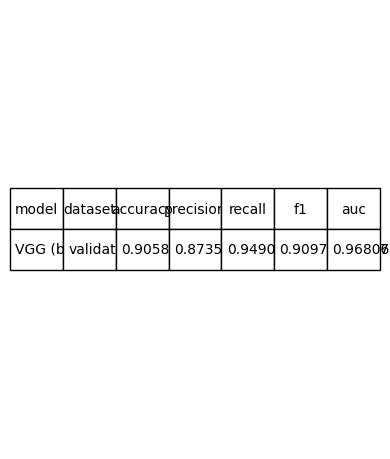

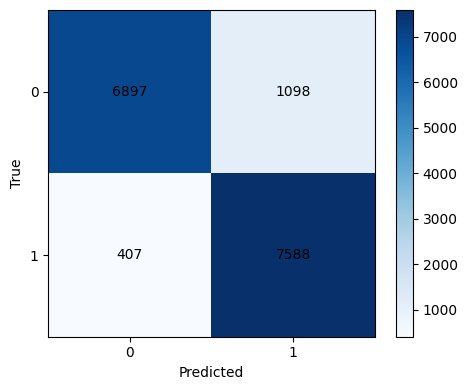

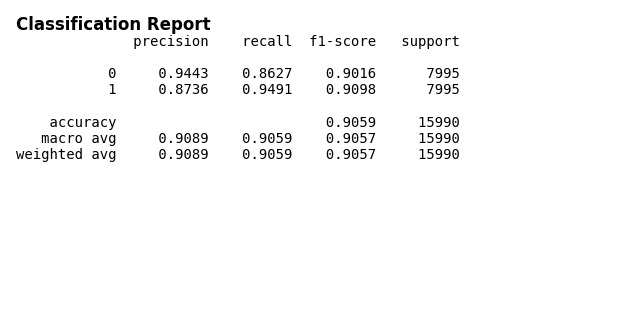

C:\Users\Brian\AppData\Local\Temp\ipykernel_28228\3506506209.py:161: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("jet")


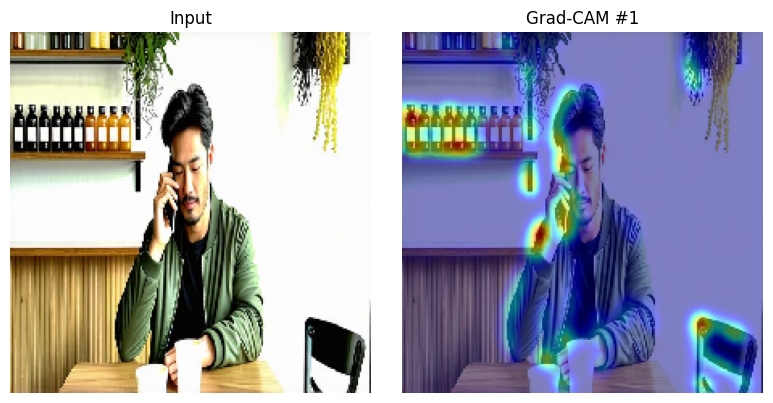

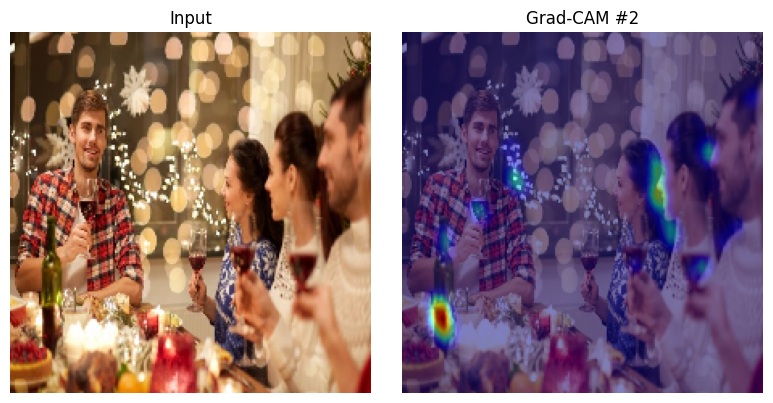

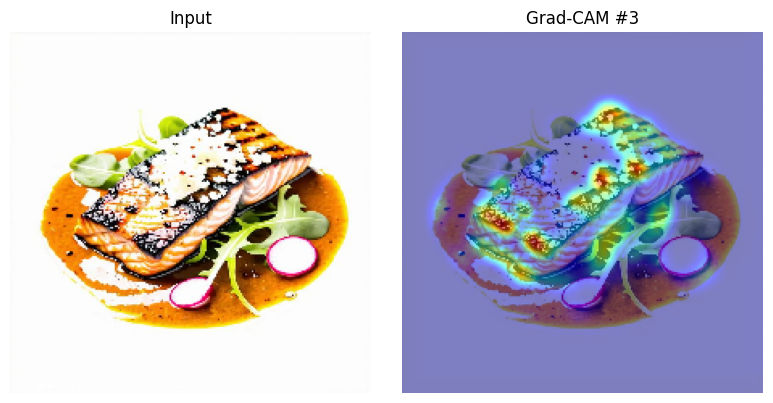

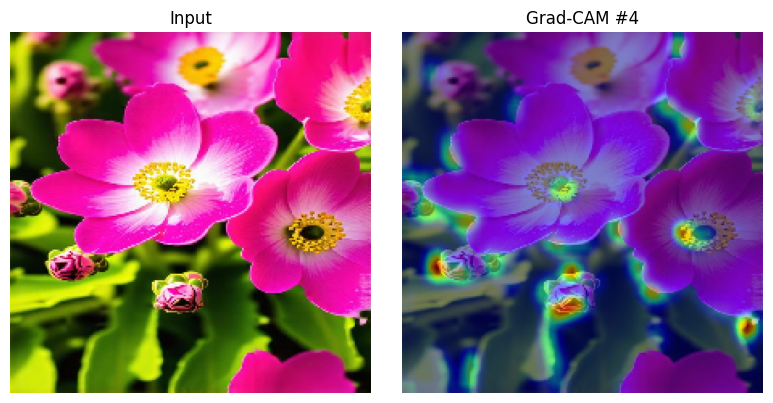

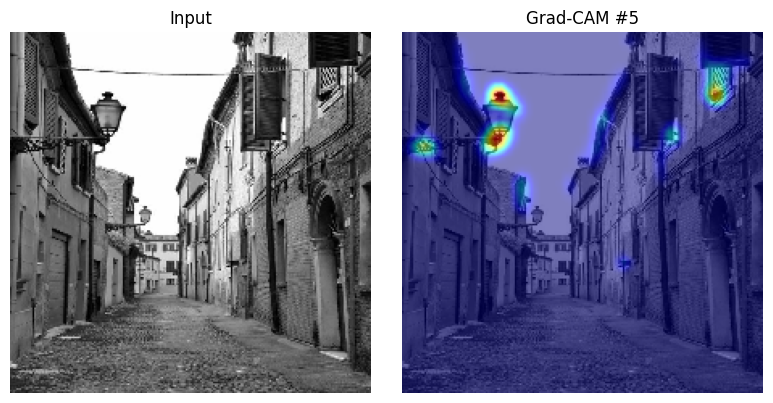

Displayed evaluation visuals (no files saved).


In [ ]:
# Replace evaluation cell: show images inline (no saving)
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import math, tensorflow as tf, pandas as pd

# load best model checkpoint
best_model_path = "best_vgg_model.h5"
model = load_model(best_model_path, compile=False)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print("Loaded model:", best_model_path)

# choose evaluation generator and true labels if available
eval_gen = None
y_true = None
if 'test_df' in globals() and 'label' in test_df.columns:
    try:
        eval_gen = validation_datagen.flow_from_dataframe(
            dataframe=test_df,
            directory=BASE_DIR,
            x_col='file_name' if 'file_name' in test_df.columns else 'id',
            y_col='label',
            target_size=(IMG_HEIGHT, IMG_WIDTH),
            batch_size=BATCH_SIZE,
            class_mode='binary',
            shuffle=False
        )
    except Exception:
        eval_gen = globals().get('test_generator', None)
    y_true = np.array(test_df['label'].astype(int).values)
    eval_name = 'test'
else:
    eval_gen = globals().get('validation_generator', None)
    if eval_gen is None:
        raise RuntimeError("validation_generator or test_generator not found in notebook namespace")
    if 'val_df' in globals() and 'label' in val_df.columns:
        y_true = np.array(val_df['label'].astype(int).values)
    eval_name = 'validation'

# predict
steps = math.ceil(eval_gen.n / eval_gen.batch_size)
preds = model.predict(eval_gen, steps=steps, verbose=1)
preds_prob = np.ravel(preds)[:eval_gen.n]
preds_label = (preds_prob >= 0.5).astype(int)

# align y_true
if y_true is not None:
    y_true = y_true[:len(preds_label)]

# Performance metrics dataframe
metrics = {}
if y_true is not None and len(y_true) == len(preds_label):
    metrics['accuracy'] = accuracy_score(y_true, preds_label)
    metrics['precision'] = precision_score(y_true, preds_label, zero_division=0)
    metrics['recall'] = recall_score(y_true, preds_label, zero_division=0)
    metrics['f1'] = f1_score(y_true, preds_label, zero_division=0)
    try:
        metrics['auc'] = float(roc_auc_score(y_true, preds_prob))
    except Exception:
        metrics['auc'] = np.nan
else:
    metrics = {k: np.nan for k in ['accuracy','precision','recall','f1','auc']}

perf_df = pd.DataFrame([{'model':'VGG (best_vgg_model.h5)', 'dataset': eval_name, **metrics}])

row = perf_df.iloc[0]
metrics = ['model', 'dataset', 'accuracy', 'precision', 'recall', 'f1', 'auc']
items = []
for m in metrics:
    if m in perf_df.columns:
        val = row[m]
        if pd.isna(val):
            s = '-'
        elif isinstance(val, (float, np.floating)):
            s = f"{val:.4f}"
        else:
            s = str(val)
        items.append([m.capitalize(), s])

# show performance table
fig, ax = plt.subplots(figsize=(4, 0.6*len(items) + 0.5))
ax.axis('off')
table = ax.table(cellText=perf_df.values, colLabels=perf_df.columns, loc='center', cellLoc='left')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1,2)
plt.tight_layout()
plt.show()
plt.close(fig)

# show training history plots (if present)
hist = globals().get('history', None)
if hist is not None:
    acc = hist.history.get('accuracy', [])
    val_acc = hist.history.get('val_accuracy', [])
    loss = hist.history.get('loss', [])
    val_loss = hist.history.get('val_loss', [])
    epochs = range(1, len(acc) + 1)
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].plot(epochs, acc, label='train_acc'); axes[0].plot(epochs, val_acc, label='val_acc'); axes[0].set_title('Accuracy'); axes[0].legend()
    axes[1].plot(epochs, loss, label='train_loss'); axes[1].plot(epochs, val_loss, label='val_loss'); axes[1].set_title('Loss'); axes[1].legend()
    plt.tight_layout(); plt.show(); plt.close(fig)

# confusion matrix + classification report (display only)
if y_true is not None and len(y_true) == len(preds_label):
    cmat = confusion_matrix(y_true, preds_label)
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cmat, cmap='Blues'); plt.colorbar(im, ax=ax)
    classes = np.unique(y_true).astype(str)
    ax.set_xticks(np.arange(len(classes))); ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    for i in range(cmat.shape[0]):
        for j in range(cmat.shape[1]):
            ax.text(j, i, cmat[i, j], ha='center', va='center', color='black')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show(); plt.close(fig)

    cr = classification_report(y_true, preds_label, digits=4)
    fig = plt.figure(figsize=(8,4)); plt.axis('off')
    plt.text(0.01, 0.98, "Classification Report", fontsize=12, weight='bold', va='top')
    plt.text(0.01, 0.92, cr, fontsize=10, va='top', family='monospace')
    plt.show(); plt.close(fig)

# Grad-CAM images (display inline up to 5)
def make_gradcam_heatmap(img_tensor, model, last_conv_name):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outs, preds = grad_model(img_tensor)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_outs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outs = conv_outs[0]
    conv_outs *= pooled_grads
    heatmap = tf.reduce_mean(conv_outs, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break

if last_conv is not None:
    eval_gen.reset()
    batch_imgs, _ = next(iter(eval_gen))
    n_show = min(5, batch_imgs.shape[0])
    for i in range(n_show):
        img = batch_imgs[i]
        img_batch = np.expand_dims(img, axis=0)
        try:
            heatmap = make_gradcam_heatmap(img_batch, model, last_conv)
        except Exception as e:
            print("Grad-CAM failed:", e)
            break
        heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
        heatmap_arr = np.array(heatmap_resized) / 255.0
        cmap = cm.get_cmap("jet")
        colored = cmap(heatmap_arr)[:, :, :3]
        disp = img.copy()
        if disp.max() <= 1.1:
            disp_img = np.uint8(255 * np.clip(disp, 0, 1))
        else:
            disp_img = np.uint8(np.clip(disp, 0, 255))
        overlay = np.uint8(255 * (0.5 * (disp_img/255.0) + 0.5 * colored))
        fig, ax = plt.subplots(1,2, figsize=(8,4))
        ax[0].imshow(disp_img); ax[0].axis('off'); ax[0].set_title('Input')
        ax[1].imshow(overlay); ax[1].axis('off'); ax[1].set_title(f'Grad-CAM #{i+1}')
        plt.tight_layout(); plt.show(); plt.close(fig)

print("Displayed evaluation visuals (no files saved).")
